# Scanner usage example

In [9]:
from pathlib import Path
from ultralytics import YOLO
from scanner_api.app_models import Scanner, OrderModel # necessary imports.
import matplotlib.pyplot as plt
import cv2

## Model loading

The `Scanner` model is a pipeline composed by two models: `YOLO` and `OrderModel`, so to use it, we have to load our `YOLO` and `OrderModel` models, then we give those models to our `Scanner` object when creating an instance.

The `YOLO` model is loaded by giving the path to a yolo model file to the `YOLO` constructor, the `OrderModel` is loaded by giving it the path to .csv file that contains the data of a base shelf in the yolo format (columns being class, x, y, w, h).

And that's it, we are ready to use it!

In [10]:
model_path = Path.cwd().parent/'models'/'my_model.pt'
shelf_path = Path.cwd().parent/'src'/'scanner_api'/'shelves'/'BATERIAS (1F) 0,36M.csv'
test_img = Path.cwd().parent/'data'/'test'/'test_img.jpeg'

yolo_model = YOLO(model_path)
order_model = OrderModel(shelf_path)

scanner = Scanner(yolo_model=yolo_model, order_model=order_model)
pred = scanner.predict(test_img)


image 1/1 c:\Users\shade\OneDrive\Documentos\Coding Projects\4geeks projects\shelf-scanner\data\test\test_img.jpeg: 640x384 1 Bateria Duracell AA 2Und, 1 Bateria Duracell AAA 2Und, 1 Bateria Energizer A23 2Und, 1 Bateria Energizer Max 9V, 2 Bateria Energizer Max AA 2Unds, 2 Bateria Energizer Max AA 4 Unds, 2 Bateria Energizer Max AAA 2 Unds, 2 Bateria Energizer Max AAA 4 Unds, 1 Bateria Energizer Max C 2 Und, 1 Bateria Energizer Max D Alkalina 2 Und, 1 Bateria Kodak 9V EHD, 2 Bateria Philips Boton Litio 2032 X5s, 4 Bateria Philips Power Alkaline AA 2Unds, 3 Bateria Philips Power Alkaline AAA 2Unds, 1 Linterna Rayovac Recargable Mini 5 Led, 2166.5ms
Speed: 117.5ms preprocess, 2166.5ms inference, 169.3ms postprocess per image at shape (1, 3, 640, 384)


## The ScannerResult class

The `predict` method of the scanner object returns a `ScannerResult` object. This object is a dataclass that stores the results of the `YOLO` and `OrderModel` models. These results can be accessed using the `yolo_result` and `order_result` properties. 

### order_result

The order result property stores a tuple containing two DataFrames.

In [11]:
print(f'order_result type: {type(pred.order_result)}')
print(f'order_result length: {len(pred.order_result)}')

order_result type: <class 'tuple'>
order_result length: 2


The first DataFrame in the tuple contains the expected SKUs in the image that is being scanned. If the `expected_SKU` was found in the image in the position its given position (`pos` column), the `detected` value will be `True` for that product, if the product in the position was different from the `expected_SKU` it will be `False`.

In [12]:
pred.order_result[0]

,pos,cls,expected_SKU,detected
0,0,4,Bateria Energizer Max AA 2Und,False
1,1,11,Bateria Philips Boton Litio 2032 X5,True
2,2,11,Bateria Philips Boton Litio 2032 X5,True
3,3,14,Linterna Rayovac Recargable Mini 5 Led,True
4,4,10,Bateria Kodak 9V EHD,True
5,5,6,Bateria Energizer Max AAA 2 Und,True
6,6,8,Bateria Energizer Max C 2 Und,True
7,7,5,Bateria Energizer Max AA 4 Und,True
8,8,7,Bateria Energizer Max AAA 4 Und,True
9,9,9,Bateria Energizer Max D Alkalina 2 Und,True


The second DataFrame has a similar structure but also contains information related to the scanned image (like xy coordinates of each product and the scanned box dimensions). In this DataFrame the `pos` column is calculated by the `OrderModel` model using the x, y values and the `detected_SKU` column stores SKU of the equivalent class detected by the `YOLO` model. 

In [13]:
pred.order_result[1]

,x,y,w,h,cls,pos,detected_SKU
0,540.811279,395.996216,233.213867,193.716309,5.0,0,Bateria Energizer Max AA 4 Und
1,692.300232,443.292603,330.437134,132.671753,11.0,1,Bateria Philips Boton Litio 2032 X5
2,826.652771,437.795227,332.142944,147.088379,11.0,2,Bateria Philips Boton Litio 2032 X5
3,984.732666,504.938324,435.024597,194.301819,14.0,3,Linterna Rayovac Recargable Mini 5 Led
4,759.278442,794.741882,224.213623,173.929199,10.0,4,Bateria Kodak 9V EHD
5,535.332092,711.091675,218.660156,192.218018,6.0,5,Bateria Energizer Max AAA 2 Und
6,926.002075,984.260254,195.237793,171.094482,8.0,6,Bateria Energizer Max C 2 Und
7,764.318054,1055.456787,187.597412,174.571045,5.0,7,Bateria Energizer Max AA 4 Und
8,555.861938,1064.339600,208.530029,181.326904,7.0,8,Bateria Energizer Max AAA 4 Und
9,970.799377,1260.321289,180.196045,166.513306,9.0,9,Bateria Energizer Max D Alkalina 2 Und


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

coor = scaler.fit_transform(pred.order_result[1][['x','y']]).T

coor

array([[    -1.4083,    -0.44068,     0.41749,      1.4272,   -0.012861,     -1.4433,      1.0521,    0.019329,     -1.3122,      1.3382, -0.00059125,      -1.347,      1.2311,    0.048909,    0.064362,     -1.2308,    0.073509,      1.2069,     -1.2179,    -0.99692,     -1.0001,      1.2795,    0.025433,
             1.1095,      1.1172],
       [     -1.688,     -1.6055,     -1.6151,     -1.4981,    -0.99319,     -1.1389,    -0.66298,    -0.53893,    -0.52345,    -0.18198,      -0.115,   -0.093366,     0.25776,     0.27411,     0.27383,     0.29449,     0.66148,     0.69262,      0.6922,      1.1017,      1.1057,      1.0844,      1.1005,
             1.5636,      1.5523]], dtype=float32)

In [15]:
import pandas as pd

ideal = pd.read_csv(shelf_path,sep=' ', names=['x','y','w','h'])

scaler = StandardScaler()

ideal = scaler.fit_transform(ideal[['x','y']]).T

ideal


array([[    0.10563,      1.4559,     -1.2337,     -1.2337,     0.13256,      1.2485,     -1.2265,     0.13256,      1.2556,     -1.2265,      0.1111,      1.2485,     -1.2337,     0.13256,      1.2628,      1.2485,     0.12541,     -1.2265,     -1.2337,     0.12541,     -1.2408,    -0.32524,     0.34716,
             1.2485],
       [     1.5508,      1.5528,      1.5586,      1.0634,      1.0711,      1.0711,     0.64524,     0.64139,     0.64139,     0.21942,     0.20593,     0.19051,    -0.20256,    -0.20448,    -0.20641,    -0.62838,    -0.62645,    -0.62645,     -1.0504,     -1.0638,     -1.4743,     -1.4723,     -1.4723,
            -1.3837]])

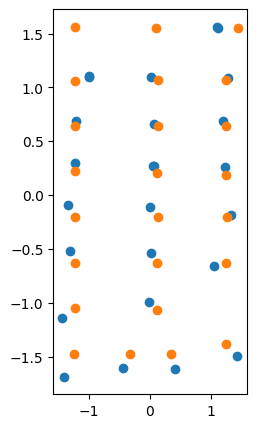

In [16]:
plt.figure(figsize=(2.5,5))
plt.scatter(coor[0], coor[1])
plt.scatter(ideal[0], ideal[1])



plt.show()

## example: printing the detection image

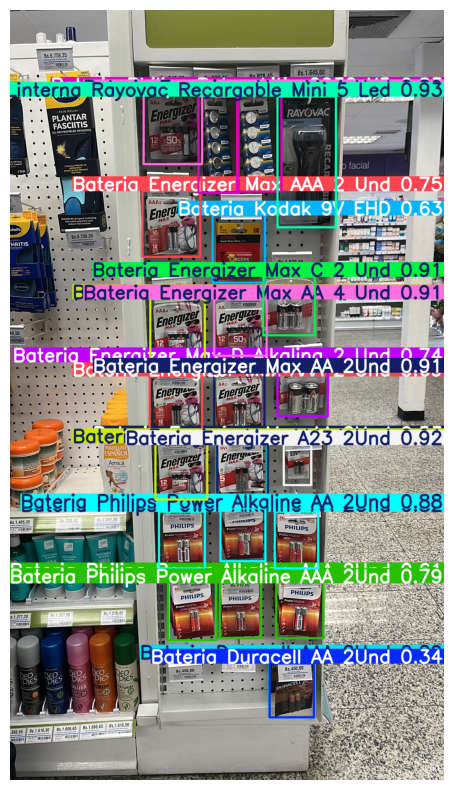

In [17]:
img_arr = pred.yolo_result.plot()
img = cv2.cvtColor(img_arr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis('off')
plt.show()

In [18]:
df = pred.order_result[1].iloc[0]

C:\Users\shade\AppData\Local\Temp\ipykernel_26480\2164715506.py:41: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  box = Rectangle(


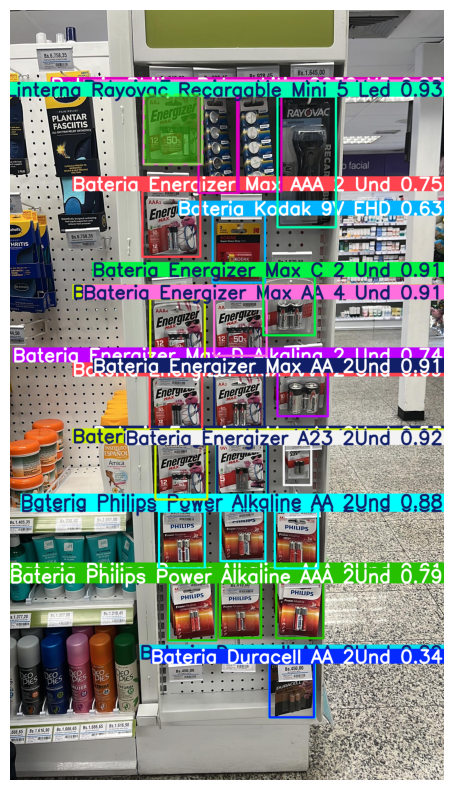

In [19]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

# --- Configuration for the box ---
# Center coordinates of the box
CENTER_X = df['x']
CENTER_Y = df['y']


# Dimensions of the box
WIDTH = df['h']
HEIGHT = df['w']

# Translucency level (alpha)
# 0.0 is fully transparent, 1.0 is fully opaque. 0.3 is 'somewhat translucent'
ALPHA_LEVEL = 0.4

# Color of the box
BOX_COLOR = '#4CFE05'

def draw_translucent_box(ax, center_x, center_y, width, height, color, alpha):
    """
    Calculates the bottom-left coordinates and adds a Rectangle patch to the Axes.

    Args:
        ax (matplotlib.axes.Axes): The axes object to draw the patch on.
        center_x (float): X-coordinate of the box center.
        center_y (float): Y-coordinate of the box center.
        width (float): Width of the box.
        height (float): Height of the box.
        color (str): Color of the box.
        alpha (float): Translucency level (0.0 to 1.0).
    """
    # 1. Calculate the bottom-left corner (x, y)
    # This is the starting point required by the Rectangle patch constructor.
    x_bottom_left = center_x - width / 2
    y_bottom_left = center_y - height / 2

    # 2. Create the Rectangle patch
    box = Rectangle(
        (x_bottom_left, y_bottom_left), # Bottom-left (x, y)
        width,                          # Width
        height,                         # Height
        color=color,                    # Fill color
        alpha=alpha,                    # Translucency
        fill=True,                      # Ensure the area is filled
        # Optional: set the edge color and style
        edgecolor=color,
        linestyle='--',
        linewidth=2
    )

    # 3. Add the patch to the Axes
    ax.add_patch(box)
    
    # Return the patch object if further manipulation is needed
    return box

# --- Main Plotting Setup ---
fig, ax = plt.subplots(figsize=(10, 10))



# 2. Draw the translucent box
highlight_box = draw_translucent_box(
    ax, 
    CENTER_X, 
    CENTER_Y, 
    WIDTH, 
    HEIGHT, 
    BOX_COLOR, 
    ALPHA_LEVEL
)

# 3. Final plot settings
ax.imshow(img)
ax.axis('off')
plt.show()

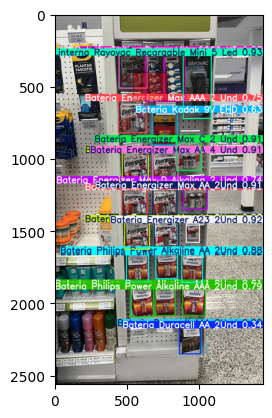

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots()

x_start = df['x']
y_start = df['y']
width = df['w']
height = df['h']

# Create the Rectangle patch
# facecolor='red' sets the color of the box
# alpha=0.3 makes it highly translucent
rect = patches.Rectangle((x_start, y_start),
                         width,
                         height,
                         linewidth=1,
                         edgecolor='black', # Border color
                         facecolor='red',
                         alpha=0.3,
                         label='Custom Box')

# Add the rectangle to the plot
ax.add_patch(rect)

# Set plot limits (important for seeing the rectangle)
ax.set_aspect('equal') # Optional: Makes the scaling equal
ax.imshow(img)


plt.show()